# <center>Discounted Cash Flow Model</center>

This notebook is a model-first walkthrough of the DCF framework used in the interactive site. The goal is to explain the logic clearly, keep the assumptions easy to inspect, and show the core valuation outputs with static charts that are simple to view on GitHub.

## Project Goal: What and Why Are We Building?

A DCF model tries to answer one central question: **what is a business worth today based on the cash it can generate in the future?**

We are building this project for two reasons:

1. **To create a transparent valuation framework**  
   Instead of jumping straight to a price target, we break the valuation into its moving parts: revenue, margins, reinvestment, tax, discounting, and terminal value.

2. **To turn the model into both a product and a teaching tool**  
   The site gives us an interactive interface. This notebook gives us a clean, readable explanation of the same model in a format that is easier to inspect on GitHub.

In this notebook, we will keep the assumptions **flat across all forecast years** so the structure stays simple. The site handles richer year-by-year customization.

# 1. Imports and Environment Setup

In [19]:
from dataclasses import replace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import pandas as pd
# Add the repository root so the shared python_model package resolves cleanly.
repo_root = Path.cwd().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

from python_model.data_api import ForecastYear, default_model_inputs
from python_model.dcf_engine import run_valuation

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 13

# 2. Data Retrieval, Cleaning, and Formatting

For the notebook, we start from the shared baseline inputs inside the Python model package. In the live app, these values are built from fetched market data and normalized provider fields. Here, we keep it deterministic and reproducible.

The purpose of this section is to take those baseline inputs and organize them into clean tables before we start modeling.

In [20]:
base_inputs = default_model_inputs()

company_base_df = pd.DataFrame(
    {
        "Field": [
            "Ticker",
            "Company Name",
            "Current Price",
            "Base Revenue",
            "Base NWC",
            "Net Debt",
            "Surplus Assets",
            "Minorities",
            "Diluted Shares",
        ],
        "Value": [
            base_inputs.company.ticker,
            base_inputs.company.company_name,
            base_inputs.company.current_price,
            base_inputs.company.revenue_base,
            base_inputs.company.base_nwc,
            base_inputs.company.net_financial_position,
            base_inputs.company.surplus_assets,
            base_inputs.company.minorities,
            base_inputs.company.diluted_shares,
        ],
    }
)

market_base_df = pd.DataFrame(
    {
        "Field": [
            "Risk-Free Rate",
            "Market Return",
            "Tax Rate",
            "Cost of Debt",
            "Beta",
            "Debt Value",
            "Equity Value",
        ],
        "Value": [
            base_inputs.market.risk_free_rate,
            base_inputs.market.market_return,
            base_inputs.market.tax_rate,
            base_inputs.market.cost_of_debt,
            base_inputs.market.beta,
            base_inputs.market.debt_value,
            base_inputs.market.equity_value,
        ],
    }
)

company_base_df

,Field,Value
0,Ticker,AAPL
1,Company Name,Apple Inc.
2,Current Price,195.0
3,Base Revenue,391035000000.0
4,Base NWC,24400000000.0
5,Net Debt,81000000000.0
6,Surplus Assets,28000000000.0
7,Minorities,0.0
8,Diluted Shares,15300000000.0


In [21]:
market_base_df

,Field,Value
0,Risk-Free Rate,4.200000e-02
1,Market Return,9.000000e-02
2,Tax Rate,2.100000e-01
3,Cost of Debt,5.000000e-02
4,Beta,1.200000e+00
5,Debt Value,1.100000e+11
6,Equity Value,2.950000e+12


# 3. Flat Assumption Setup

Before we run the DCF, these are the main assumptions you can modify in this notebook:

- `projection_years`
- `revenue_growth`
- `ebitda_margin`
- `depreciation_rate`
- `capex_rate`
- `nwc_rate`
- `tax_rate`
- `wacc`
- `terminal_growth`
- `net_debt`
- `diluted_shares_outstanding`

Unlike the site, this notebook applies one flat value to all forecast years so the mechanics stay easy to read.

In [22]:
projection_years = 5

flat_assumptions = {
    "revenue_growth": 0.055,
    "ebitda_margin": 0.320,
    "depreciation_rate": 0.030,
    "capex_rate": 0.040,
    "nwc_rate": 0.062,
    "tax_rate": 0.210,
    "wacc": 0.083,
    "terminal_growth": 0.025,
    "net_debt": base_inputs.company.net_financial_position,
    "diluted_shares_outstanding": base_inputs.company.diluted_shares,
}

assumptions_df = pd.DataFrame(
    {
        "Assumption": list(flat_assumptions.keys()),
        "Value": list(flat_assumptions.values()),
    }
)
assumptions_df

,Assumption,Value
0,revenue_growth,5.500000e-02
1,ebitda_margin,3.200000e-01
2,depreciation_rate,3.000000e-02
3,capex_rate,4.000000e-02
4,nwc_rate,6.200000e-02
5,tax_rate,2.100000e-01
6,wacc,8.300000e-02
7,terminal_growth,2.500000e-02
8,net_debt,8.100000e+10
9,diluted_shares_outstanding,1.530000e+10


In [23]:
forecast_years = [
    ForecastYear(
        year=year,
        revenue_growth=flat_assumptions["revenue_growth"],
        ebitda_margin=flat_assumptions["ebitda_margin"],
        depreciation_rate=flat_assumptions["depreciation_rate"],
        capex_rate=flat_assumptions["capex_rate"],
        nwc_rate=flat_assumptions["nwc_rate"],
        tax_rate=flat_assumptions["tax_rate"],
    )
    for year in range(1, projection_years + 1)
]

notebook_company = replace(
    base_inputs.company,
    net_financial_position=flat_assumptions["net_debt"],
    diluted_shares=flat_assumptions["diluted_shares_outstanding"],
)

notebook_market = replace(
    base_inputs.market,
    tax_rate=flat_assumptions["tax_rate"],
    wacc_override=flat_assumptions["wacc"],
)

notebook_inputs = replace(
    base_inputs,
    company=notebook_company,
    market=notebook_market,
    forecast_years=forecast_years,
    terminal_growth_rate=flat_assumptions["terminal_growth"],
)

pd.DataFrame([vars(year) for year in notebook_inputs.forecast_years])

,year,revenue_growth,ebitda_margin,depreciation_rate,capex_rate,nwc_rate,tax_rate
0,1,0.055,0.32,0.03,0.04,0.062,0.21
1,2,0.055,0.32,0.03,0.04,0.062,0.21
2,3,0.055,0.32,0.03,0.04,0.062,0.21
3,4,0.055,0.32,0.03,0.04,0.062,0.21
4,5,0.055,0.32,0.03,0.04,0.062,0.21


# 4. Formula Walkthrough

We now go formula by formula. Each step explains **what the formula does**, **which inputs go into it**, and **why that step matters** in the broader valuation.


## Step 1: Revenue Forecast

The forecast starts with revenue because almost every other operating line is modeled from it.

$$
\text{Revenue}_t = \text{Revenue}_{t-1} \times (1 + g_t)
$$

Where:

- $\text{Revenue}_{t-1}$ = revenue in the prior year
- $g_t$ = revenue growth rate in year $t$

**Use of the formula:** this gives us the top line for each forecast year.


## Step 2: EBITDA

Once revenue is projected, we estimate operating profitability before depreciation and amortization.

$$
\text{EBITDA}_t = \text{Revenue}_t \times m_t^{\text{EBITDA}}
$$

Where:

- $\text{Revenue}_t$ = projected revenue in year $t$
- $m_t^{\text{EBITDA}}$ = EBITDA margin in year $t$

**Use of the formula:** EBITDA tells us how much operating profit the business earns before non-cash charges and before financing decisions.


## Step 3: Depreciation and Amortization, EBIT, and NOPAT

We estimate D\&A as a percentage of revenue, subtract it from EBITDA to get EBIT, and then apply tax to get NOPAT.

$$
\text{D\&A}_t = \text{Revenue}_t \times d_t
$$

$$
\text{EBIT}_t = \text{EBITDA}_t - \text{D\&A}_t
$$

$$
\text{NOPAT}_t = \text{EBIT}_t \times (1 - \tau_t)
$$

Where:

- $d_t$ = depreciation and amortization rate
- $\tau_t$ = tax rate in year $t$

**Use of the formula:** NOPAT is the after-tax operating profit generated by the business, before financing effects.


## Step 4: Working Capital and CapEx

A business needs reinvestment to sustain and grow. We capture that through working capital and capital expenditure.

$$
\text{NWC}_t = \text{Revenue}_t \times n_t
$$

$$
\Delta \text{NWC}_t = \text{NWC}_t - \text{NWC}_{t-1}
$$

$$
\text{CapEx}_t = \text{Revenue}_t \times c_t
$$

Where:

- $n_t$ = net working capital as a percent of revenue
- $c_t$ = capital expenditure as a percent of revenue

**Use of the formula:** these terms represent the cash reinvestment required to keep the operating engine running.


## Step 5: Unlevered Free Cash Flow (UFCF)

Now we combine operating profit, non-cash charges, and reinvestment needs.

$$
\text{UFCF}_t = \text{NOPAT}_t + \text{D\&A}_t - \text{CapEx}_t - \Delta \text{NWC}_t
$$

**Use of the formula:** UFCF is the cash flow available to all capital providers before debt payments are considered.


## Step 6: Discounting, Terminal Value, and Equity Value

Once UFCF is projected, we discount it back to today and then bridge from enterprise value to equity value.

$$
PV(\text{UFCF}_t) = \frac{\text{UFCF}_t}{(1 + WACC)^t}
$$

$$
TV_n = \frac{\text{UFCF}_n \times (1 + g)}{WACC - g}
$$

$$
EV = \sum PV(\text{UFCF}_t) + PV(TV_n)
$$

$$
\text{Equity Value} = EV + \text{Surplus Assets} - \text{Minorities} - \text{Net Debt}
$$

$$
\text{Implied Share Price} = \frac{\text{Equity Value}}{\text{Diluted Shares Outstanding}}
$$

Where:

- $WACC$ = weighted average cost of capital
- $g$ = terminal growth rate

**Use of the formula:** this is the final conversion from forecast cash generation into per-share value.


# 5. Running the DCF Model

In [9]:
valuation = run_valuation(notebook_inputs)

summary = valuation["summary"]
forecast_df = valuation["forecast_df"].copy()
bridge_df = valuation["bridge_df"].copy()
sensitivity_df = valuation["sensitivity_df"].copy()
diagnostics = valuation["diagnostics"]


# 6. Summary Statistics

In [10]:
summary_table = pd.DataFrame(
    [
        {"Metric": "Company", "Value": summary["company_name"]},
        {"Metric": "Ticker", "Value": summary["ticker"]},
        {"Metric": "Current Price", "Value": summary["current_price"]},
        {"Metric": "Computed WACC", "Value": summary["computed_wacc"]},
        {"Metric": "Terminal Growth", "Value": summary["terminal_growth_rate"]},
        {"Metric": "Enterprise Value", "Value": summary["enterprise_value"]},
        {"Metric": "Equity Value", "Value": summary["equity_value"]},
        {"Metric": "Implied Share Price", "Value": summary["implied_share_price"]},
        {"Metric": "Upside / Downside", "Value": summary["upside_downside"]},
        {"Metric": "Terminal Value Weight", "Value": summary["terminal_value_weight"]},
    ]
)
summary_table


,Metric,Value
0,Company,Apple Inc.
1,Ticker,AAPL
2,Current Price,195.0
3,Computed WACC,0.083
4,Terminal Growth,0.025
5,Enterprise Value,1699211480924.631348
6,Equity Value,1646211480924.631348
7,Implied Share Price,107.595522
8,Upside / Downside,-0.448228
9,Terminal Value Weight,0.770144


# 7. Forecast Table

This table is the year-by-year operating model behind the valuation.


In [11]:
forecast_df[[
    "Year",
    "Revenue",
    "EBITDA",
    "Depreciation",
    "EBIT",
    "NOPAT",
    "NWC",
    "Delta NWC",
    "Capex",
    "FCFF",
    "PV of FCFF",
]]


,Year,Revenue,EBITDA,Depreciation,EBIT,NOPAT,NWC,Delta NWC,Capex,FCFF,PV of FCFF
0,1,4.125419e+11,1.320134e+11,1.237626e+10,1.196372e+11,9.451336e+10,2.557760e+10,1.177599e+09,1.650168e+10,8.921034e+10,8.237335e+10
1,2,4.352317e+11,1.392742e+11,1.305695e+10,1.262172e+11,9.971159e+10,2.698437e+10,1.406768e+09,1.740927e+10,9.395250e+10,8.010349e+10
2,3,4.591695e+11,1.469342e+11,1.377508e+10,1.331591e+11,1.051957e+11,2.846851e+10,1.484140e+09,1.836678e+10,9.911989e+10,7.803249e+10
3,4,4.844238e+11,1.550156e+11,1.453271e+10,1.404829e+11,1.109815e+11,3.003428e+10,1.565768e+09,1.937695e+10,1.045715e+11,7.601503e+10
4,5,5.110671e+11,1.635415e+11,1.533201e+10,1.482095e+11,1.170855e+11,3.168616e+10,1.651885e+09,2.044268e+10,1.103229e+11,7.404973e+10


# 8. Static DCF Charts

The charts below are the static notebook version of the visuals used in the site.

Before changing the chart calculations, the main assumptions to modify are the flat values in `flat_assumptions` above:

- Revenue Growth
- EBITDA margin
- D\&A rate
- CapEx rate
- NWC rate
- Tax rate
- WACC
- Terminal Growth
- Net Debt
- Diluted Shares Outstanding

We are intentionally keeping them flat here so the analysis stays clean and readable.

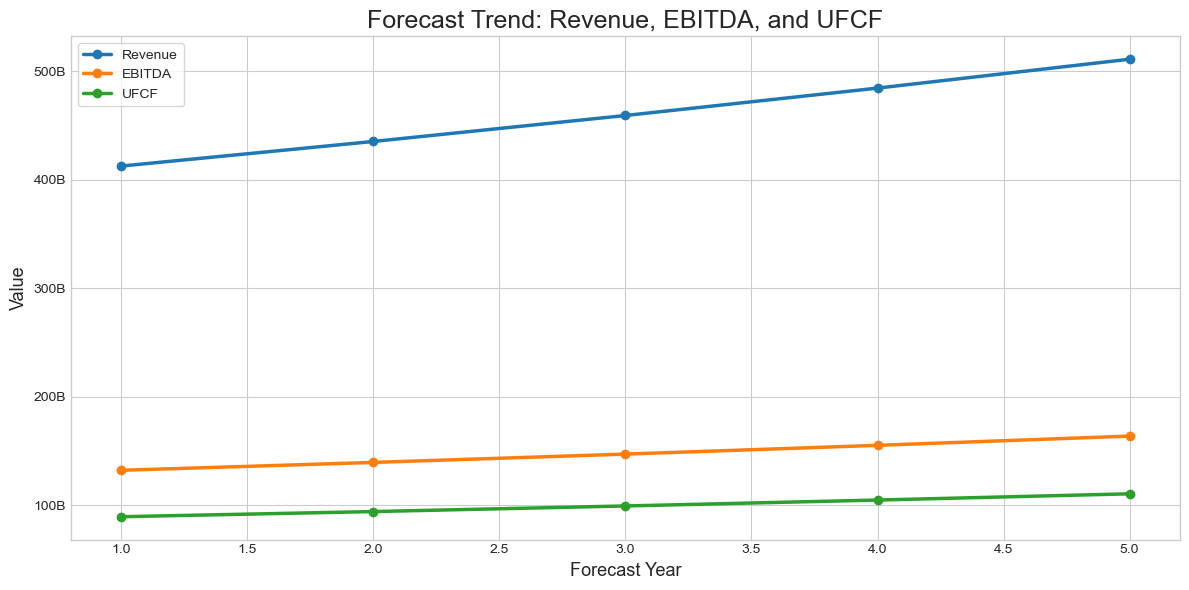

In [16]:
def billions(x, pos):
    return f"{x/1e9:,.0f}B"

chart_df = forecast_df[["Year", "Revenue", "EBITDA", "FCFF"]].copy()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(chart_df["Year"], chart_df["Revenue"], marker="o", linewidth=2.5, label="Revenue")
ax.plot(chart_df["Year"], chart_df["EBITDA"], marker="o", linewidth=2.5, label="EBITDA")
ax.plot(chart_df["Year"], chart_df["FCFF"], marker="o", linewidth=2.5, label="UFCF")
ax.yaxis.set_major_formatter(FuncFormatter(billions))
ax.set_title("Forecast Trend: Revenue, EBITDA, and UFCF")
ax.set_xlabel("Forecast Year")
ax.set_ylabel("Value")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

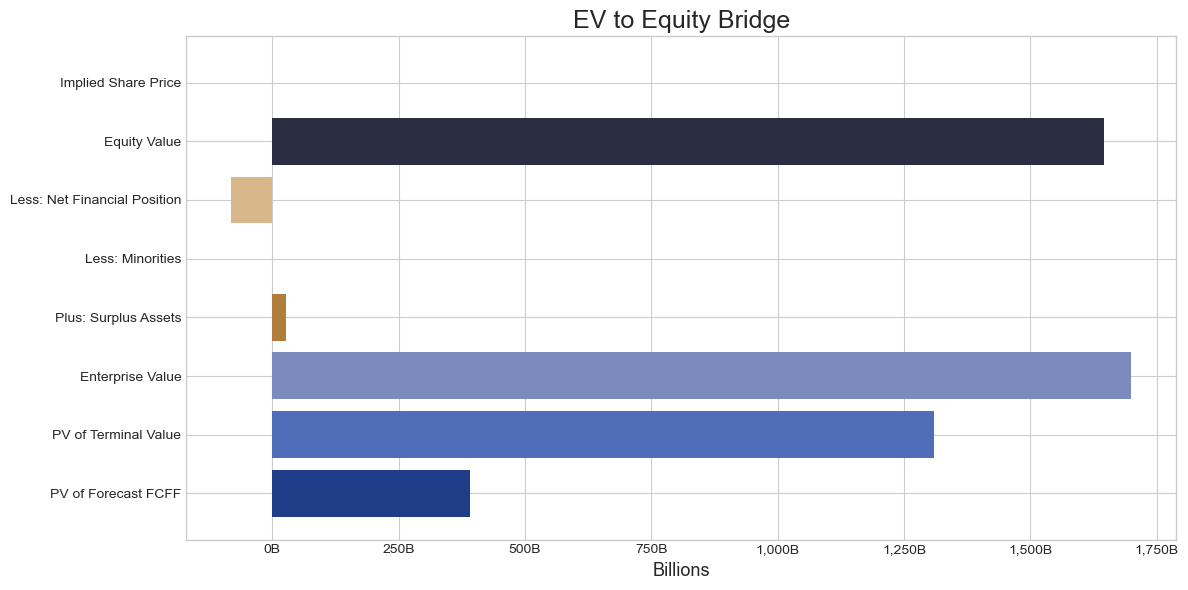

In [17]:
bridge_chart = bridge_df.copy()
bridge_chart["ValueBillions"] = bridge_chart["Value"] / 1e9

fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#1f3c88", "#4f6db8", "#7b8bbd", "#b07d3c", "#c99b5f", "#d8b88a", "#2b2d42", "#0d1b2a"]
ax.barh(bridge_chart["Metric"], bridge_chart["ValueBillions"], color=colors[: len(bridge_chart)])
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:,.0f}B")
ax.set_title("EV to Equity Bridge")
ax.set_xlabel("Billions")
plt.tight_layout()
plt.show()

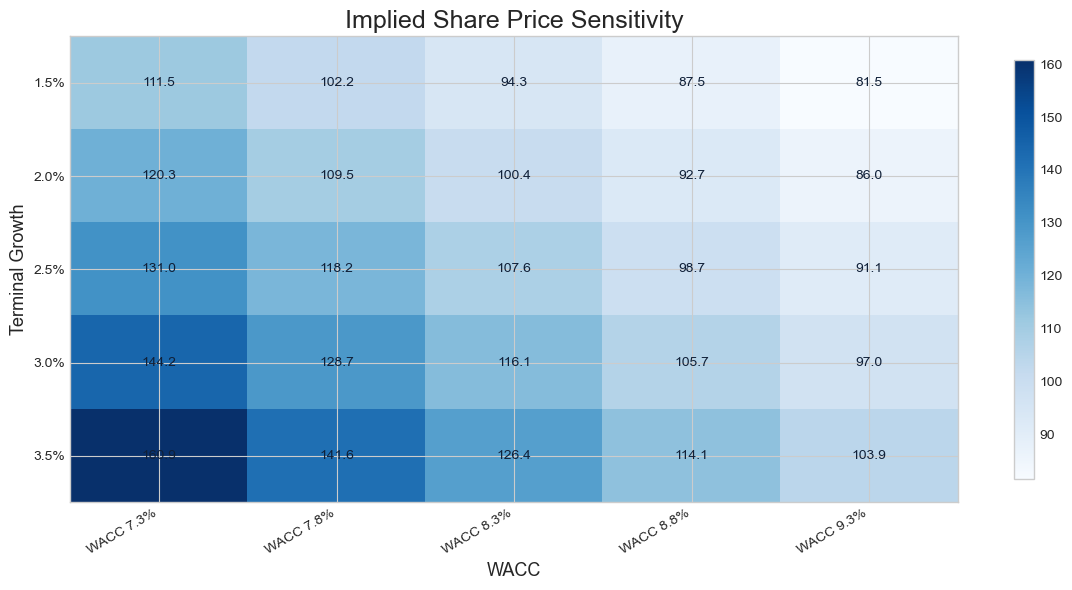

In [18]:
heatmap_df = sensitivity_df.copy()
heatmap_df["Terminal Growth"] = heatmap_df["Terminal Growth"].map(lambda x: f"{x:.1%}")
heatmap_df = heatmap_df.set_index("Terminal Growth")

fig, ax = plt.subplots(figsize=(12, 6))
image = ax.imshow(heatmap_df.values, cmap="Blues", aspect="auto")
ax.set_title("Implied Share Price Sensitivity")
ax.set_xlabel("WACC")
ax.set_ylabel("Terminal Growth")
ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns, rotation=30, ha="right")
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)

for row in range(heatmap_df.shape[0]):
    for col in range(heatmap_df.shape[1]):
        value = heatmap_df.iloc[row, col]
        ax.text(col, row, f"{value:.1f}", ha="center", va="center", color="#102038", fontsize=10)

fig.colorbar(image, ax=ax, shrink=0.9)
plt.tight_layout()
plt.show()